In [34]:
import gc
import re
from pathlib import Path

import matplotlib.pyplot as plt
import nltk
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from nltk.stem.snowball import SnowballStemmer
from nltk.tokenize import word_tokenize, sent_tokenize
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import Dataset, DataLoader

# По условию используем именно нужную видеокарту.
device = torch.device("cuda:0")
print('device:', device)

PROJECT_DIR = Path('.') if Path('data').exists() else Path('Текущий контроль 7-8')
DATA_DIR = PROJECT_DIR / 'data'

MODELS_DIR = PROJECT_DIR / 'saved_models'
MODELS_DIR.mkdir(exist_ok=True)

criterion = nn.CrossEntropyLoss()


device: cuda:0


In [35]:
nltk.download('punkt')
try:
    nltk.download('punkt_tab')
except Exception:
    pass


[nltk_data] Downloading package punkt to /home/aleksey/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/aleksey/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


## 1. Представление и предобработка текстовых данных 

1.1 Операции по предобработке:
* токенизация
* стемминг / лемматизация
* удаление стоп-слов
* удаление пунктуации
* приведение к нижнему регистру
* любые другие операции над текстом

In [36]:
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem.snowball import SnowballStemmer

stemmer = SnowballStemmer('english')


def clear_memory(*objects):
    for obj in objects:
        del obj
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def train_classifier(model, train_loader, test_loader, criterion, optimizer, epochs, device, patience=None, min_delta=0.0):
    model = model.to(device)
    history = {'train_loss': [], 'test_loss': [], 'test_acc': []}
    best_test_loss = float('inf')
    best_state = None
    epochs_without_improvement = 0

    for epoch in range(epochs):
        model.train()
        train_loss_sum = 0.0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()

            train_loss_sum += loss.item() * X_batch.size(0)

        train_loss = train_loss_sum / len(train_loader.dataset)
        test_loss, test_acc = evaluate_classifier(model, test_loader, criterion, device)
        history['train_loss'].append(train_loss)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)
        print(f'epoch {epoch + 1}/{epochs}: train_loss={train_loss:.4f} test_loss={test_loss:.4f} test_acc={test_acc:.4f}')

        if test_loss < best_test_loss - min_delta:
            best_test_loss = test_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if patience is not None and epochs_without_improvement >= patience:
                print(f'early stopping at epoch {epoch + 1}')
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return history


def evaluate_classifier(model, loader, criterion, device):
    model.eval()
    losses = []
    y_true = []
    y_pred = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            losses.append(loss.item() * X_batch.size(0))
            preds = logits.argmax(dim=1)
            y_true.extend(y_batch.cpu().tolist())
            y_pred.extend(preds.cpu().tolist())

    mean_loss = sum(losses) / len(loader.dataset)
    acc = accuracy_score(y_true, y_pred)
    return mean_loss, acc


def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history['train_loss'], label='train')
    axes[0].plot(history['test_loss'], label='test')
    axes[0].set_title(title + ' loss')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(history['test_acc'], label='test_acc', color='green')
    axes[1].set_title(title + ' accuracy')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def make_class_weights(targets):
    counts = pd.Series(targets).value_counts().sort_index()
    weights = 1.0 / torch.tensor(counts.values, dtype=torch.float32)
    weights = weights / weights.sum() * len(weights)
    return weights


def show_text_predictions(model, texts, labels, vectorize_fn, label_encoder, device, n=5, title='Examples'):
    print(title)
    model.eval()
    for text, label in list(zip(texts, labels))[:n]:
        with torch.no_grad():
            vector = vectorize_fn(text).unsqueeze(0).to(device)
            probs = torch.softmax(model(vector), dim=1).squeeze(0)
            pred_idx = int(torch.argmax(probs).item())
        true_label = label_encoder.inverse_transform([int(label)])[0]
        pred_label = label_encoder.inverse_transform([pred_idx])[0]
        preview = str(text).replace('\n', ' ')[:180]
        print(f'true={true_label} | pred={pred_label} | text={preview}...')


In [37]:
text = 'Select your preferences and run the install command. Stable represents the most currently tested and supported version of PyTorch. Note that LibTorch is only available for C++'


def preprocess_text(text: str):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z.!?]+', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = word_tokenize(text)
    processed_tokens = []

    for token in tokens:
        if re.fullmatch(r'[.!?]', token):
            continue
        processed_tokens.append(stemmer.stem(token))

    return processed_tokens

print('processed_tokens:', preprocess_text(text))


processed_tokens: ['select', 'your', 'prefer', 'and', 'run', 'the', 'instal', 'command', 'stabl', 'repres', 'the', 'most', 'current', 'test', 'and', 'support', 'version', 'of', 'pytorch', 'note', 'that', 'libtorch', 'is', 'onli', 'avail', 'for', 'c']


Реализовать функцию `preprocess_text(text: str)`, которая:
* приводит строку к нижнему регистру
* заменяет все символы, кроме a-z, A-Z и знаков .,!? на пробел


1.2 Представление текстовых данных при помощи бинарного кодирования


Представить первое предложение из `text` в виде тензора `sentence_t`: `sentence_t[i] == 1`, если __слово__ с индексом `i` присуствует в предложении.

In [38]:
class Vocab:
    def __init__(self, data, specials=None):
        unique_tokens = sorted(set(data))
        specials = specials or []
        self.idx_to_token = specials + [token for token in unique_tokens if token not in specials]
        self.token_to_idx = {token: idx for idx, token in enumerate(self.idx_to_token)}
        self.vocab_len = len(self.idx_to_token)


first_sentence = sent_tokenize(text)[0]
first_sentence_tokens = preprocess_text(first_sentence)
all_tokens = sorted(set(preprocess_text(text)))
word_vocab_demo = Vocab(all_tokens)

sentence_t = torch.zeros(word_vocab_demo.vocab_len, dtype=torch.float32)
for token in first_sentence_tokens:
    sentence_t[word_vocab_demo.token_to_idx[token]] = 1.0

print('first_sentence_tokens:', first_sentence_tokens)
print('sentence_t shape:', sentence_t.shape)
print('sentence_t:', sentence_t)

first_sentence_tokens: ['select', 'your', 'prefer', 'and', 'run', 'the', 'instal', 'command']
sentence_t shape: torch.Size([25])
sentence_t: tensor([1., 0., 0., 1., 0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 1., 1.,
        0., 0., 0., 0., 1., 0., 1.])


## 2. Классификация фамилий по национальности

Датасет: https://disk.yandex.ru/d/owHew8hzPc7X9Q?w=1

2.1 Считать файл `surnames/surnames.csv`. 

2.2 Закодировать национальности числами, начиная с 0.

2.3 Разбить датасет на обучающую и тестовую выборку

2.4 Реализовать класс `Vocab` (токен = __символ__)

2.5 Реализовать класс `SurnamesDataset`

2.6. Обучить классификатор.

2.7 Измерить точность на тестовой выборке. Проверить работоспособность модели: прогнать несколько фамилий студентов группы через модели и проверить результат. Для каждой фамилии выводить 3 наиболее вероятных предсказания.

surnames_df columns: ['surname', 'nationality']
epoch 1/15: train_loss=2.8007 test_loss=2.6397 test_acc=0.2664
epoch 2/15: train_loss=2.3867 test_loss=2.2134 test_acc=0.3811
epoch 3/15: train_loss=2.0399 test_loss=2.0083 test_acc=0.4335
epoch 4/15: train_loss=1.8401 test_loss=1.8790 test_acc=0.4171
epoch 5/15: train_loss=1.7009 test_loss=1.7632 test_acc=0.4367
epoch 6/15: train_loss=1.5814 test_loss=1.7073 test_acc=0.4836
epoch 7/15: train_loss=1.4700 test_loss=1.6528 test_acc=0.4681
epoch 8/15: train_loss=1.3989 test_loss=1.5998 test_acc=0.5068
epoch 9/15: train_loss=1.3247 test_loss=1.5990 test_acc=0.5064
epoch 10/15: train_loss=1.2758 test_loss=1.5635 test_acc=0.5246
epoch 11/15: train_loss=1.2182 test_loss=1.5505 test_acc=0.5159
epoch 12/15: train_loss=1.1616 test_loss=1.5213 test_acc=0.5387
epoch 13/15: train_loss=1.1278 test_loss=1.5249 test_acc=0.5487
epoch 14/15: train_loss=1.0983 test_loss=1.4944 test_acc=0.5638
epoch 15/15: train_loss=1.0404 test_loss=1.5251 test_acc=0.5542


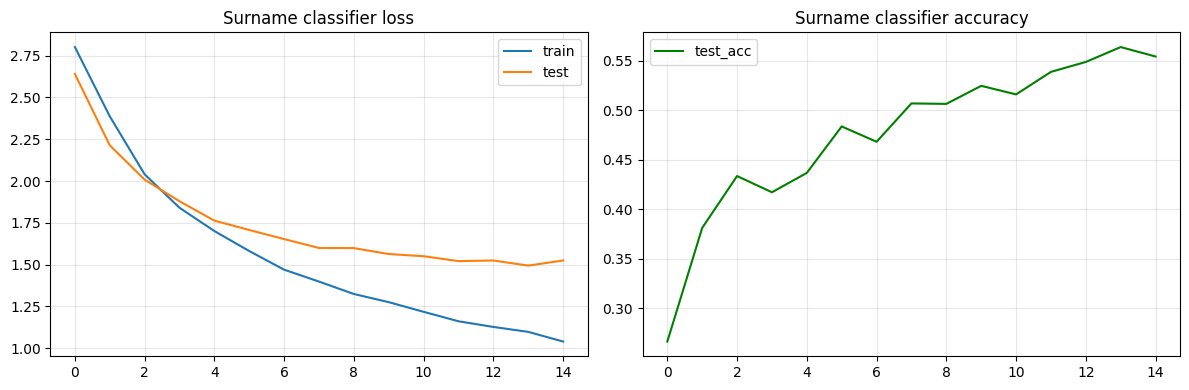

Surname classifier accuracy: 0.563752276867031
Ivanov -> [('Russian', 0.9543240666389465), ('Czech', 0.03480358049273491), ('English', 0.0034261757973581553)]
Petrov -> [('Russian', 0.686527669429779), ('Czech', 0.2198987603187561), ('English', 0.04215403273701668)]
Smith -> [('Scottish', 0.5022486448287964), ('German', 0.1674952208995819), ('Dutch', 0.09237098693847656)]
Kim -> [('Korean', 0.6751653552055359), ('Chinese', 0.12248701602220535), ('Vietnamese', 0.06845314800739288)]
Garcia -> [('Portuguese', 0.41132232546806335), ('Italian', 0.3656695485115051), ('Spanish', 0.16679807007312775)]


In [39]:
class SurnamesDataset(Dataset):
    def __init__(self, X, y, vocab: Vocab, max_len):
        self.X = list(X)
        self.y = list(y)
        self.vocab = vocab
        self.max_len = max_len

    def vectorize(self, surname):
        """Кодирует фамилию как последовательность символов с паддингом до фиксированной длины."""
        pad_idx = self.vocab.token_to_idx['<PAD>']
        unk_idx = self.vocab.token_to_idx['<UNK>']
        indices = [self.vocab.token_to_idx.get(char, unk_idx) for char in surname.lower()[:self.max_len]]
        if len(indices) < self.max_len:
            indices += [pad_idx] * (self.max_len - len(indices))
        return torch.tensor(indices, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.vectorize(self.X[idx]), torch.tensor(self.y[idx], dtype=torch.long)


surnames_path = DATA_DIR / 'surnames.csv'
surnames_df = pd.read_csv(surnames_path)
print('surnames_df columns:', surnames_df.columns.tolist())

label_encoder = LabelEncoder()
surnames_df['target'] = label_encoder.fit_transform(surnames_df['nationality'])

X_train, X_test, y_train, y_test = train_test_split(
    surnames_df['surname'],
    surnames_df['target'],
    test_size=0.2,
    random_state=42,
    stratify=surnames_df['target'],
)

char_vocab = Vocab(''.join(X_train.astype(str).str.lower().tolist()), specials=['<PAD>', '<UNK>'])
max_surname_len = int(X_train.astype(str).str.len().quantile(0.95))
max_surname_len = max(max_surname_len, 8)
train_dataset = SurnamesDataset(X_train.tolist(), y_train.tolist(), char_vocab, max_surname_len)
test_dataset = SurnamesDataset(X_test.tolist(), y_test.tolist(), char_vocab, max_surname_len)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

class SurnameClassifier(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, output_dim, pad_idx):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_idx)
        self.gru = nn.GRU(emb_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_dim * 2, output_dim)

    def forward(self, x):
        embedded = self.embedding(x)
        _, hidden = self.gru(embedded)
        hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)
        hidden = self.dropout(hidden)
        return self.fc(hidden)

class_weights = make_class_weights(y_train.tolist()).to(device)
surname_criterion = nn.CrossEntropyLoss(weight=class_weights)
surname_model = SurnameClassifier(char_vocab.vocab_len, 32, 64, len(label_encoder.classes_), char_vocab.token_to_idx['<PAD>'])
optimizer = optim.Adam(surname_model.parameters(), lr=1e-3, weight_decay=1e-4)
history_surnames = train_classifier(surname_model, train_loader, test_loader, surname_criterion, optimizer, epochs=15, device=device, patience=4, min_delta=1e-3)
plot_history(history_surnames, 'Surname classifier')

test_loss, test_acc = evaluate_classifier(surname_model, test_loader, surname_criterion, device)
print('Surname classifier accuracy:', test_acc)


def predict_surname(model, surname, vocab, label_encoder, top_k=3):
    model.eval()
    with torch.no_grad():
        vector = train_dataset.vectorize(surname).unsqueeze(0).to(device)
        probs = torch.softmax(model(vector), dim=1).squeeze(0)
        top_probs, top_idx = torch.topk(probs, k=top_k)
        results = []
        for prob, idx in zip(top_probs.cpu().tolist(), top_idx.cpu().tolist()):
            results.append((label_encoder.inverse_transform([idx])[0], prob))
        return results

sample_surnames = ['Ivanov', 'Petrov', 'Smith', 'Kim', 'Garcia']
for surname in sample_surnames:
    print(surname, '->', predict_surname(surname_model, surname, char_vocab, label_encoder))

torch.save(surname_model.state_dict(), MODELS_DIR / 'surname_classifier.pth')
clear_memory(surname_model, history_surnames, optimizer, surname_criterion)


## 3. Классификация обзоров ресторанов

Датасет: https://disk.yandex.ru/d/nY1o70JtAuYa8g

3.1 Считать файл `yelp/raw_train.csv`. Оставить от исходного датасета 10% строчек.

3.2 Воспользоваться функцией `preprocess_text` из 1.1 для обработки текста отзыва. Закодировать рейтинг числами, начиная с 0.

3.3 Разбить датасет на обучающую и тестовую выборку

3.4 Реализовать класс `Vocab` (токен = слово)

3.5 Реализовать класс `ReviewDataset`

3.6 Обучить классификатор

3.7 Измерить точность на тестовой выборке. Проверить работоспособность модели: придумать небольшой отзыв, прогнать его через модель и вывести номер предсказанного класса (сделать это для явно позитивного и явно негативного отзыва)


In [40]:
class Vocab:
    def __init__(self, data, min_freq=1):
        counts = pd.Series(data).value_counts()
        unique_tokens = sorted(counts[counts >= min_freq].index.tolist())
        self.idx_to_token = unique_tokens
        self.token_to_idx = {token: idx for idx, token in enumerate(unique_tokens)}
        self.vocab_len = len(unique_tokens)


yelp_df shape after sampling: (56000, 2)
epoch 1/8: train_loss=0.3249 test_loss=0.2068 test_acc=0.9196
epoch 2/8: train_loss=0.1777 test_loss=0.1974 test_acc=0.9221
epoch 3/8: train_loss=0.1401 test_loss=0.2055 test_acc=0.9204
epoch 4/8: train_loss=0.1081 test_loss=0.2134 test_acc=0.9187
early stopping at epoch 4


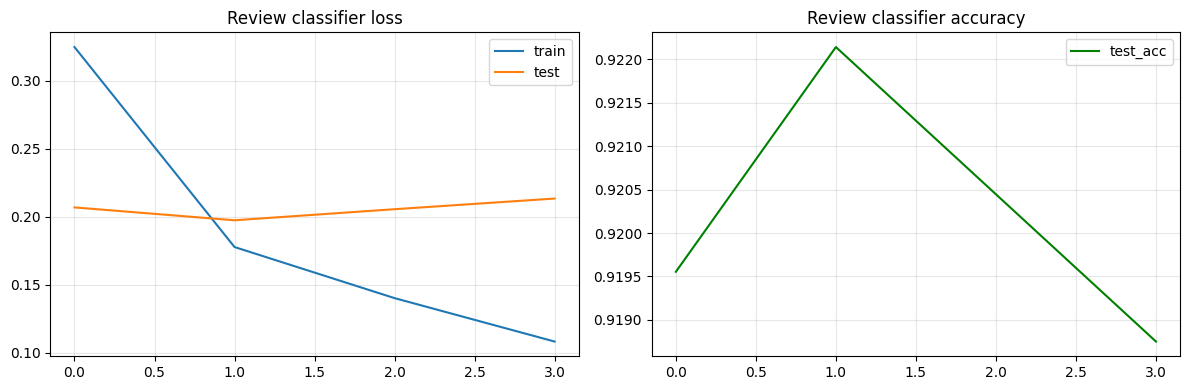

Review classifier accuracy: 0.9221428571428572
Test review examples
true=2 | pred=2 | text=I love this place. I am one of these people who love spa services and love a good deal.\n\n Here is what I recommend. Get on the email list for SWIHA, and you will get emailed all ...
true=2 | pred=2 | text=Every time I go to Scottsdale, I have to come here for dinner.  Since it is only about once a year, I HAVE to have the BBQ Salmon!  It is consistantly awesome, I promise.  We start...
true=2 | pred=2 | text=While visiting my son in AZ we decided to stop in here for dinner. It wasn't too busy (day after Thanksgiving) and the weather was nice so we sat on the patio. The patio is really ...
true=1 | pred=1 | text=The food here was T-e-r-r-i-b-l-e!  Service was so-so...Don't waste your money here....
true=1 | pred=1 | text=My sister and I was shopping at this mall a while back and I am now writing this review bc I just created a yelp account. So we went and try out this place for manicures. My gel

In [41]:
class ReviewDataset(Dataset):
    def __init__(self, X, y, vocab: Vocab):
        self.X = list(X)
        self.y = list(y)
        self.vocab = vocab

    def vectorize(self, review):
        """Генерирует представление отзыва review при помощи бинарного кодирования (см. 1.2)"""
        vector = torch.zeros(self.vocab.vocab_len, dtype=torch.float32)
        for word in preprocess_text(review):
            if word in self.vocab.token_to_idx:
                vector[self.vocab.token_to_idx[word]] = 1.0
        return vector

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.vectorize(self.X[idx]), torch.tensor(self.y[idx], dtype=torch.long)


yelp_path = DATA_DIR / 'raw_train.csv'
yelp_df = pd.read_csv(yelp_path, header=None, names=['rating', 'text'])
yelp_df = yelp_df.sample(frac=0.1, random_state=42).reset_index(drop=True)
print('yelp_df shape after sampling:', yelp_df.shape)

label_encoder_reviews = LabelEncoder()
yelp_df['target'] = label_encoder_reviews.fit_transform(yelp_df['rating'])

X_train, X_test, y_train, y_test = train_test_split(
    yelp_df['text'],
    yelp_df['target'],
    test_size=0.2,
    random_state=42,
    stratify=yelp_df['target'],
)

train_tokens = []
for review in X_train:
    train_tokens.extend(preprocess_text(str(review)))

word_vocab = Vocab(train_tokens, min_freq=5)
review_train_dataset = ReviewDataset(X_train.tolist(), y_train.tolist(), word_vocab)
review_test_dataset = ReviewDataset(X_test.tolist(), y_test.tolist(), word_vocab)

review_train_loader = DataLoader(review_train_dataset, batch_size=256, shuffle=True)
review_test_loader = DataLoader(review_test_dataset, batch_size=512, shuffle=False)

class ReviewClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim // 2, output_dim),
        )

    def forward(self, x):
        return self.net(x)

review_model = ReviewClassifier(word_vocab.vocab_len, 128, len(label_encoder_reviews.classes_))
optimizer = optim.Adam(review_model.parameters(), lr=7e-4, weight_decay=1e-4)
history_reviews = train_classifier(review_model, review_train_loader, review_test_loader, criterion, optimizer, epochs=8, device=device, patience=2, min_delta=1e-3)
plot_history(history_reviews, 'Review classifier')

test_loss, test_acc = evaluate_classifier(review_model, review_test_loader, criterion, device)
print('Review classifier accuracy:', test_acc)
show_text_predictions(review_model, X_test.tolist(), y_test.tolist(), review_train_dataset.vectorize, label_encoder_reviews, device, n=5, title='Test review examples')


def predict_review(model, review_text, vocab, label_encoder):
    model.eval()
    with torch.no_grad():
        vector = review_train_dataset.vectorize(review_text).unsqueeze(0).to(device)
        pred = model(vector).argmax(dim=1).item()
        return label_encoder.inverse_transform([pred])[0]

positive_review = 'Amazing food, polite staff and fast service. I will definitely come back again.'
negative_review = 'Terrible food, rude staff and a very bad experience. I do not recommend this place.'

print('positive_review ->', predict_review(review_model, positive_review, word_vocab, label_encoder_reviews))
print('negative_review ->', predict_review(review_model, negative_review, word_vocab, label_encoder_reviews))

torch.save(review_model.state_dict(), MODELS_DIR / 'review_classifier.pth')
clear_memory(review_model, history_reviews, optimizer)
